In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers
import random

import umap
import shap
import hdbscan

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Data Setup

In [2]:
def flatten_mnist(data):
    return data.reshape(data.shape[0], data.shape[1] * data.shape[2])

def random_sample(X, y, n, random_state=1):
    random.seed(random_state)
    sample = random.sample(range(X.shape[0]), n)

    return X[sample], y[sample]

In [21]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

random_state = 2019
samp_train = random.sample(range(X_train.shape[0]), 20000)
samp_test = random.sample(range(X_test.shape[0]), 5000)

X_train = X_train[samp_train,:,:]
y_train = y_train[samp_train]

X_test = X_train[samp_test,:,:]
y_test = y_train[samp_test]

# Neural Network

In [77]:
len(X_train.shape)

3

In [24]:
model_cnn = keras.Sequential(
    [
        keras.Input(shape=(28,28,1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ]
)

model_cnn.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

model_cnn.fit(X_train, y_train, batch_size=128, epochs = 15, shuffle = True)

scores = model_cnn.evaluate(X_test, y_test)
print(model_cnn.metrics_names[0], model_cnn.metrics_names[1])

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6249 - loss: 5.3299
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8813 - loss: 0.7227
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9345 - loss: 0.2224
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9520 - loss: 0.1629
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9577 - loss: 0.1376
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9656 - loss: 0.1109
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9693 - loss: 0.0964
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9744 - loss: 0.0811
Epoch 9/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9769 - loss: 0.0745
Epoch 10/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9783 - loss: 0.0658
Epoch 11/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9779 - loss: 0.0646
Epoch 12/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 

NameError: name 'model_nn' is not defined

In [25]:
print(classification_report(y_test, np.argmax(model_cnn.predict(X_test), axis = -1)))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       466
           1       1.00      0.99      1.00       568
           2       1.00      1.00      1.00       507
           3       1.00      1.00      1.00       490
           4       1.00      1.00      1.00       490
           5       1.00      1.00      1.00       463
           6       1.00      1.00      1.00       515
           7       1.00      0.99      1.00       524
           8       0.99      1.00      0.99       457
           9       0.99      0.99      0.99       520

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



## SHAP

In [72]:
f(X_test.reshape(X_test.shape[0], 28, 28))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [75]:
def f(data):
    x = data.reshape(data.shape[0], 28, 28)
    return model_cnn.predict(x)

explainer_cnn = shap.KernelExplainer(f, shap.kmeans(X_train.reshape(X_train.shape[0], 28*28), k=30))
explanation_cnn = explainer_cnn(X_test.reshape(X_test.shape[0], 28*28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


  0%|                                                  | 0/5000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
3036/3036 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


  0%|                                       | 1/5000 [00:12<17:48:48, 12.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3036/3036 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
3036/3036 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


  0%|                                       | 3/5000 [00:37<17:17:16, 12.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2721/3036 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

  0%|                                       | 3/5000 [00:48<22:23:29, 16.13s/it]


KeyboardInterrupt: 

In [32]:
explainer_cnn = shap.KernelExplainer(model_cnn.predict, X_train)
explanation_cnn = explainer_cnn(X_test)

# np.savetxt("mnist_shap_vals_flat.csv", explanation_nn.values.reshape(5000, -1), delimiter=',')
# np.savetxt("mnist_base_vals_flat.csv", delimiter=',')

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


Using 20000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


DimensionError: Instance must have 1 or 2 dimensions!

In [27]:
vals = np.array(pd.read_csv("mnist_shap_vals_flat.csv", header=None)).reshape(5000, 784, 10)
base_vals = np.array(pd.read_csv("mnist_base_vals_flat.csv", header=None))

explanation_nn = shap.Explanation(values=vals,
                                  base_values=base_vals,
                                  data=X)

/var/folders/7_/f25wqpvj6qz4hhj2lydnm6cr0000gn/T/ipykernel_9170/1788875441.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation_nn, max_display=10, show=False, class_names=["Digit " + str(i) for i in range(10)], class_inds='original')


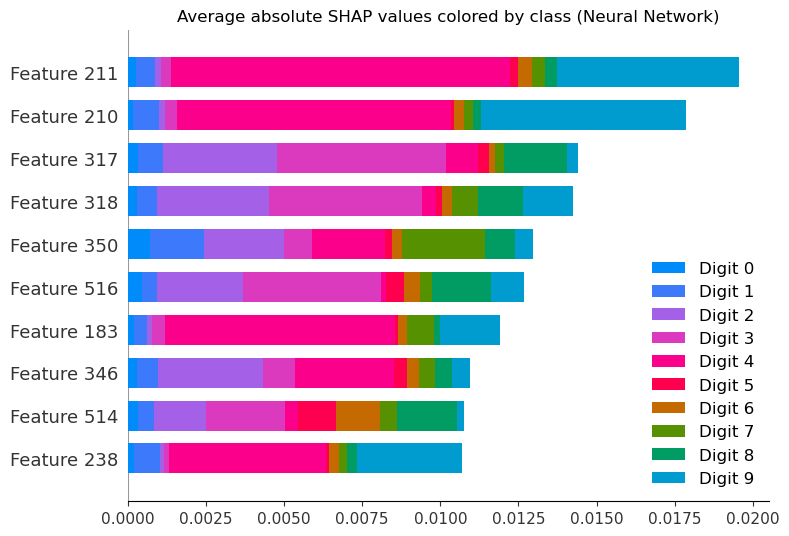

In [28]:
shap.summary_plot(explanation_nn, max_display=10, show=False, class_names=["Digit " + str(i) for i in range(10)], class_inds='original')
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class (Neural Network)")
ax.set_xlabel("")
plt.show()

In [29]:
SHAP_flat_nn = pd.DataFrame(np.asarray([explanation_nn.values[i].flatten() for i in range(explanation_nn.values.shape[0])]),
                            columns=[str(i) + '_' + str(j) for i in range(784) for j in range(10)])

# SHAP_flat_nn.to_csv("../../DATA/model comparison/MNIST/mnist_shap_nn.csv", index=False)

In [30]:
X_umap_SHAP_nn = umap.UMAP(random_state=29218).fit_transform(SHAP_flat_nn)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'ADNI SHAP values colored according to patient status')

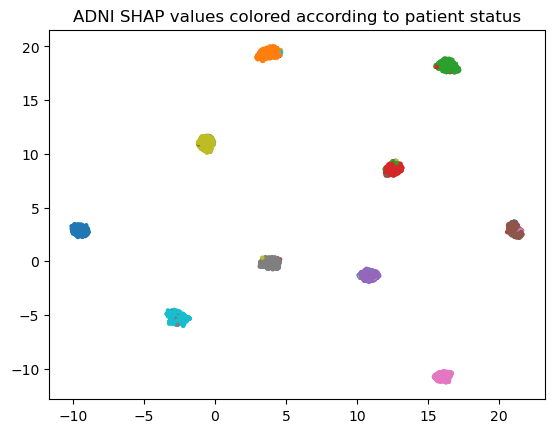

In [31]:
plt.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in y_test], s=5)
plt.title("ADNI SHAP values colored according to patient status")

# Combined

Text(0.5, 1.0, 'Neural Network')

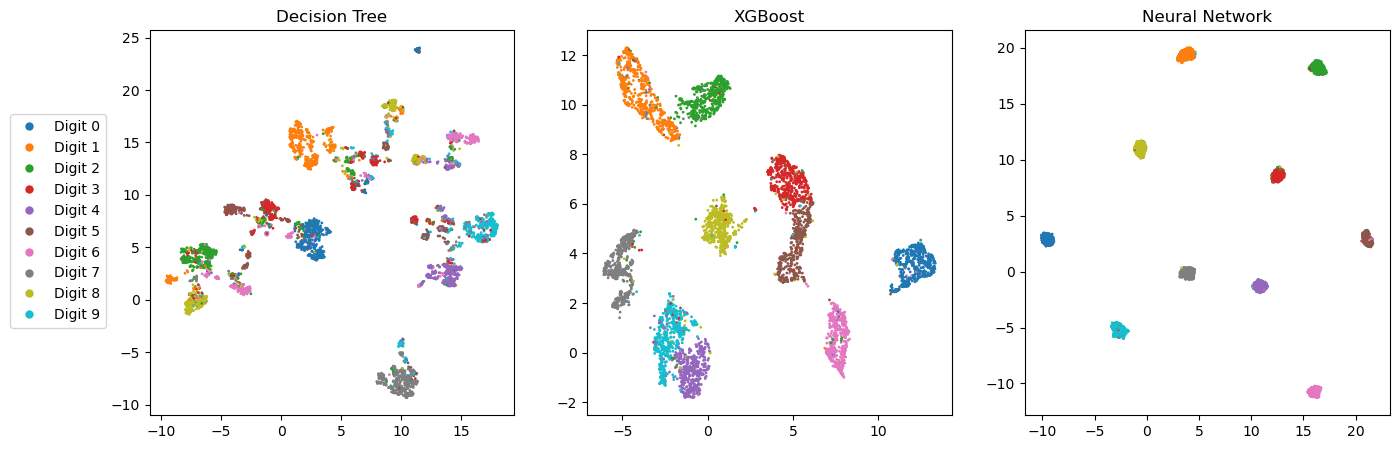

In [32]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in y_test], s=1)
ax1.set_title("Decision Tree")

labels = ["Digit " + str(i) for i in range(10)]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(10)]
ax1.legend(handles=handles, bbox_to_anchor=(-0.1, 0.8))

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in y_test], s=1)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in y_test], s=1)
ax3.set_title("Neural Network")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step


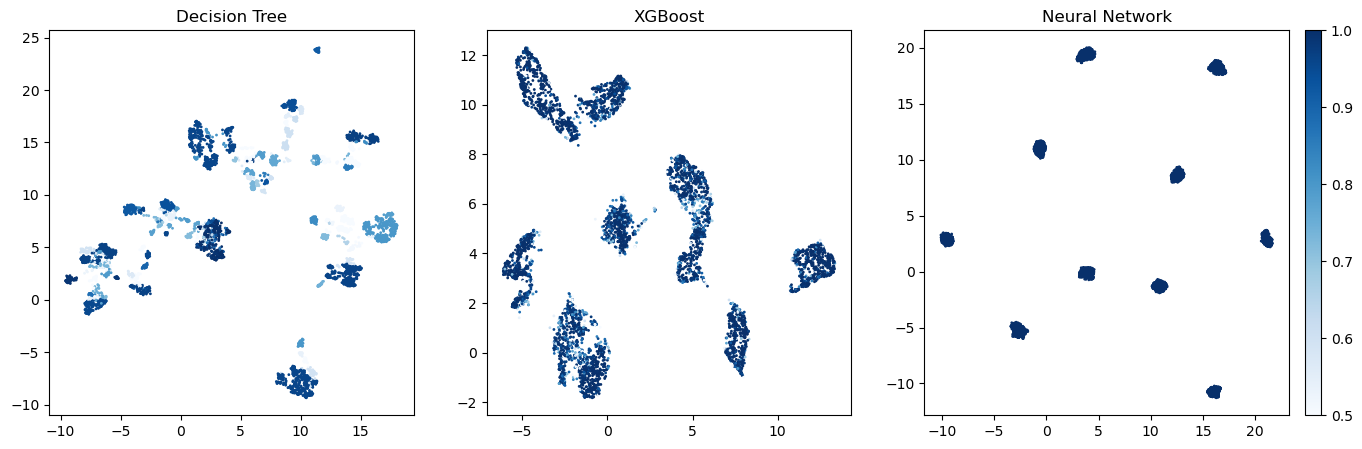

In [97]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=np.amax(clf.predict_proba(X_test), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=1)
ax1.set_title("Decision Tree")

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=np.amax(model_xgb.predict_proba(X_test), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=1)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=np.amax(model_nn.predict(X_test), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=1)
ax3.set_title("Neural Network")

ax_cbar = f.add_axes([ax3.get_position().get_points()[1,0] + 0.01,
                      ax3.get_position().get_points()[0,1],
                      0.01,
                      ax3.get_position().get_points()[1,1] - ax3.get_position().get_points()[0,1]])


f.colorbar(cm.ScalarMappable(norm=colors.Normalize(0.5, 1), cmap="Blues"), cax=ax_cbar)